# Лабораторная работа №1

**Вариант 1**

**Тема:** Исследование вычислительной сложности алгоритмов и экспериментальное сравнение производительности операций Python.

В работе выполнены задания 1–5 для варианта 1. Эксперименты используют модуль `timeit`, а графики построены с помощью `matplotlib`.

## Задание 1

Дана функция `foo`, реализующая сортировку списка методом пузырька.

### 1. Что выполняет функция?

Функция последовательно сравнивает соседние элементы списка и меняет их местами, если левый элемент больше правого. После нескольких проходов максимальные элементы перемещаются в конец списка. В результате список сортируется по возрастанию.

### 2. Вычислительная сложность

Внешний цикл выполняет до `N` проходов, а внутренний — до `N` сравнений. Поэтому в худшем и среднем случае вычислительная сложность составляет **O(N²)**.

Для уже отсортированного списка приведённая реализация всё равно выполняет те же вложенные циклы, поэтому без дополнительной проверки на отсутствие обменов её сложность остаётся **O(N²)**.

Память, используемая самой функцией, — **O(1)** дополнительной памяти, поскольку перестановка выполняется на месте.

In [2]:
def foo(a):
    for i in range(len(a), 0, -1):
        for j in range(1, i):
            if a[j-1] > a[j]:
                a[j-1], a[j] = a[j], a[j-1]
    return a

a = [1, 2, 3, 4, 2, 1, 3, 4, 3, 5, -2, -2, 2, -2, 65, 2, 2]
print("Исходный список:", a)
print("Результат:", foo(a.copy()))

Исходный список: [1, 2, 3, 4, 2, 1, 3, 4, 3, 5, -2, -2, 2, -2, 65, 2, 2]
Результат: [-2, -2, -2, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 4, 4, 5, 65]


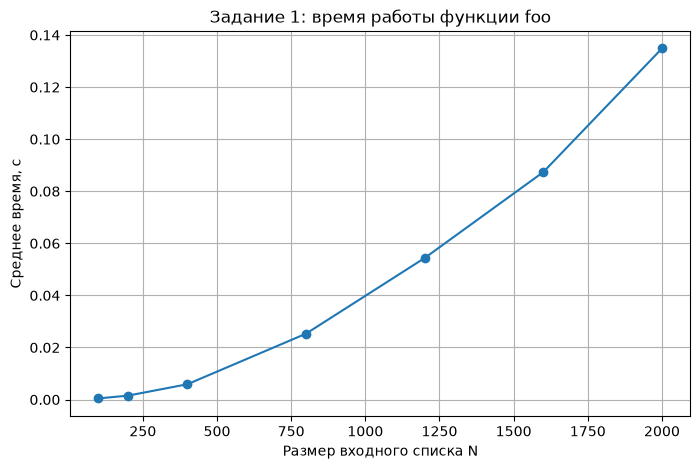

In [6]:
import random
import timeit
import matplotlib.pyplot as plt

sizes = [100, 200, 400, 800, 1200, 1600, 2000]
times = []

for n in sizes:
    data = [random.randint(-10000, 10000) for i in range(n)]
    t = timeit.timeit(lambda: foo(data.copy()), number=3) / 3
    times.append(t)

plt.figure(figsize=(8, 5))
plt.plot(sizes, times, marker="o")
plt.xlabel("Размер входного списка N")
plt.ylabel("Среднее время, с")
plt.title("Задание 1: время работы функции foo")
plt.grid(True)
plt.show()

## Задание 2

**Условие:** дан список случайных чисел. Определить значения минимального и максимального элементов списка.

Рассмотрим два алгоритма.

**Алгоритм 1:** один проход по списку с ручным обновлением минимума и максимума.

**Алгоритм 2:** сортировка списка и взятие первого и последнего элементов.

Асимптотические сложности:

- Алгоритм 1: **O(N)** по времени и **O(1)** дополнительной памяти.
- Алгоритм 2: **O(N log N)** по времени для стандартной сортировки Python; требуется дополнительная память для копии списка в нашей реализации эксперимента.

In [10]:
def min_max_linear(nums):
    if not nums:
        raise ValueError("Список не должен быть пустым")

    mn = mx = nums[0]
    for x in nums[1:]:
        if x < mn:
            mn = x
        if x > mx:
            mx = x
    return mn, mx


def min_max_sort(nums):
    if not nums:
        raise ValueError("Список не должен быть пустым")

    sorted_nums = sorted(nums)
    return sorted_nums[0], sorted_nums[-1]


test = [7, -2, 10, 4, 0, -8, 15]
print("Алгоритм 1:", min_max_linear(test))
print("Алгоритм 2:", min_max_sort(test))

Алгоритм 1: (-8, 15)
Алгоритм 2: (-8, 15)


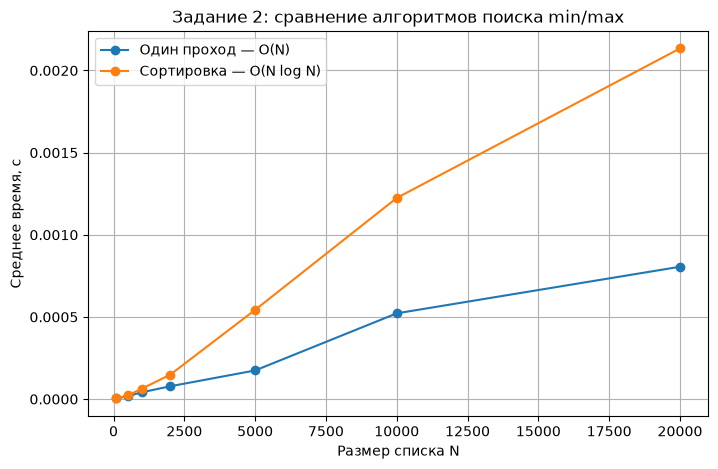

In [9]:
sizes2 = [100, 500, 1000, 2000, 5000, 10000, 20000]
linear_times = []
sort_times = []

for n in sizes2:
    data = [random.randint(-10**6, 10**6) for i in range(n)]
    linear_times.append(timeit.timeit(lambda: min_max_linear(data), number=20) / 20)
    sort_times.append(timeit.timeit(lambda: min_max_sort(data), number=5) / 5)

plt.figure(figsize=(8, 5))
plt.plot(sizes2, linear_times, marker="o", label="Один проход — O(N)")
plt.plot(sizes2, sort_times, marker="o", label="Сортировка — O(N log N)")
plt.xlabel("Размер списка N")
plt.ylabel("Среднее время, с")
plt.title("Задание 2: сравнение алгоритмов поиска min/max")
plt.legend()
plt.grid(True)
plt.show()

### Вывод по заданию 2

Однопроходный алгоритм выполняет только необходимое количество сравнений и имеет линейную сложность O(N). Алгоритм с сортировкой сначала упорядочивает весь список, поэтому его сложность выше — O(N log N). При увеличении размера входных данных разница во времени выполнения становится заметнее.

## Задание 3

`T1(N) = N^2 - N - 10`
`T2(N) = 4N + 40`

Определите размер массива N, для которого время выполнения обоих алгоритмов
одинаково.

In [13]:
import sympy as sp

N = sp.symbols('N')
T1 = N**2 - N - 10
T2 = 4*N + 40

print("Первый алгоритм:")
print("T1(N) =", T1)
print("\nВторой алгоритм:")
print("T2(N) =", T2)

equation = sp.Eq(T1, T2)
print("\nУравнение:")
print(equation)

roots = sp.solve(equation, N)

print("\nКорни уравнения:")
for root in roots:
    print(root)

valid_N = [root for root in roots if root.is_real and root > 0][0]

print("\nПодходящий размер массива:")
print("N =", valid_N)

operations_1 = T1.subs(N, valid_N)
operations_2 = T2.subs(N, valid_N)

print("\nПроверка:")
print("T1(10) =", operations_1)
print("T2(10) =", operations_2)


Первый алгоритм:
T1(N) = N**2 - N - 10

Второй алгоритм:
T2(N) = 4*N + 40

Уравнение:
Eq(N**2 - N - 10, 4*N + 40)

Корни уравнения:
-5
10

Подходящий размер массива:
N = 10

Проверка:
T1(10) = 80
T2(10) = 80


## Задание 4

Проведём эксперимент для оператора `del`:

- для списка удаляется элемент по индексу;
- для словаря удаляется элемент по ключу.

Для корректного сравнения размер входных данных увеличивается. В словаре ключи заранее известны, а для списка удаляется элемент из середины, поэтому операция для списка требует сдвига последующих элементов.

Теоретически удаление элемента из списка по индексу в общем случае имеет сложность **O(N)** из-за возможного сдвига элементов. Удаление элемента из словаря по ключу в среднем имеет сложность **O(1)**.

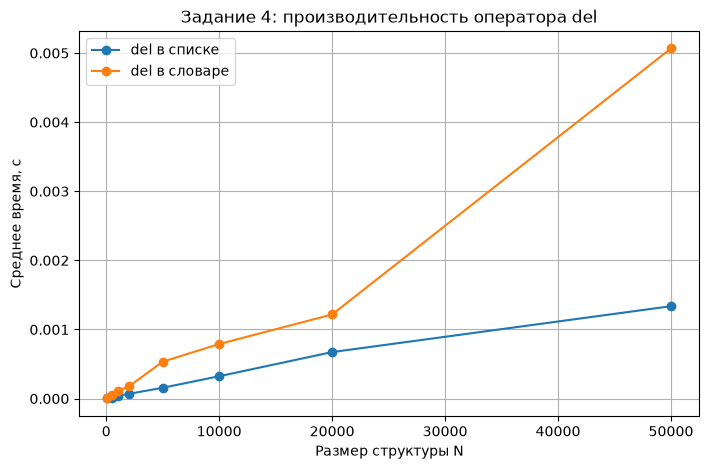

In [14]:
def delete_from_list(n):
    data = list(range(n))
    del data[n // 2]


def delete_from_dict(n):
    data = {i: i for i in range(n)}
    del data[n // 2]


sizes4 = [100, 500, 1000, 2000, 5000, 10000, 20000, 50000]
list_del_times = []
dict_del_times = []

for n in sizes4:
    list_del_times.append(timeit.timeit(lambda: delete_from_list(n), number=20) / 20)
    dict_del_times.append(timeit.timeit(lambda: delete_from_dict(n), number=20) / 20)

plt.figure(figsize=(8, 5))
plt.plot(sizes4, list_del_times, marker="o", label="del в списке")
plt.plot(sizes4, dict_del_times, marker="o", label="del в словаре")
plt.xlabel("Размер структуры N")
plt.ylabel("Среднее время, с")
plt.title("Задание 4: производительность оператора del")
plt.legend()
plt.grid(True)
plt.show()

### Вывод по заданию 4

При удалении элемента из середины списка приходится сдвигать часть элементов, поэтому время зависит от размера списка. Удаление по ключу из словаря в среднем выполняется за постоянное время O(1), хотя фактическое время также зависит от реализации и состояния структуры данных.

## Задание 5

Сравним оператор `in` для множества и списка.

- Для списка поиск выполняется последовательным просмотром элементов, поэтому в среднем и в худшем случае сложность составляет **O(N)**.
- Для множества проверка принадлежности в среднем имеет сложность **O(1)**, а в худшем случае — O(N).

В эксперименте будем искать отсутствующий элемент. Это заставляет список просмотреть все элементы и позволяет наглядно сравнить поведение структур.

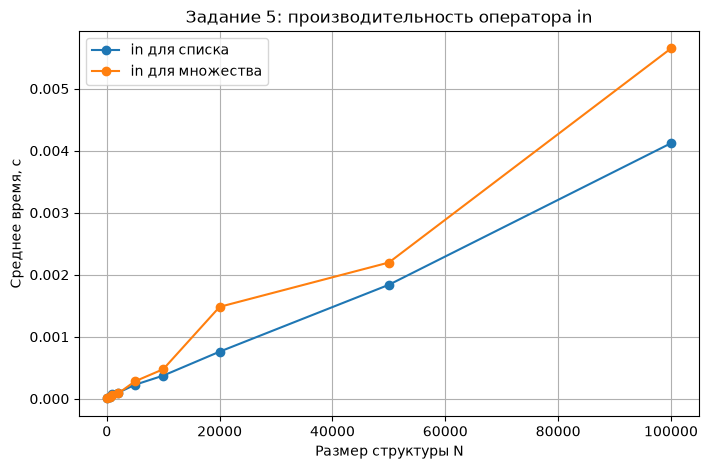

In [15]:
def contains_in_list(n):
    data = list(range(n))
    return -1 in data


def contains_in_set(n):
    data = set(range(n))
    return -1 in data


sizes5 = [100, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]
list_in_times = []
set_in_times = []

for n in sizes5:
    list_in_times.append(timeit.timeit(lambda: contains_in_list(n), number=20) / 20)
    set_in_times.append(timeit.timeit(lambda: contains_in_set(n), number=20) / 20)

plt.figure(figsize=(8, 5))
plt.plot(sizes5, list_in_times, marker="o", label="in для списка")
plt.plot(sizes5, set_in_times, marker="o", label="in для множества")
plt.xlabel("Размер структуры N")
plt.ylabel("Среднее время, с")
plt.title("Задание 5: производительность оператора in")
plt.legend()
plt.grid(True)
plt.show()

### Вывод по заданию 5

Эксперимент показывает различие между линейным поиском в списке и проверкой принадлежности множеству. При увеличении N время поиска отсутствующего элемента в списке растёт значительно быстрее. Для множества среднее время проверки принадлежности остаётся близким к постоянному.
